In [1]:
import torch
import torch.nn.functional as F

## Util functions :)

In [4]:
def set_ksp(k_shape, s_value, p_value, ones_k=None):
    """k_shape should be (in_channels, out_channels, height, width)"""
    k = torch.ones(size=k_shape) if ones_k else torch.randn(size=k_shape)
    return k, s_value, p_value

In [ ]:
import matplotlib.pyplot as plt

def visualize(o):
    plt.figure(figsize=(3,3))
    plt.imshow(o.squeeze(0), cmap='gray')
    plt.tight_layout()
    plt.show()

## Shape test (scaling factor = 2, 4, 10, or other even numbers)

In [15]:
# scaling factor = 2 
k, s, p = set_ksp((1,1,4,4), 2, 1)
print("k:", k)
print("s:", s)
print("p:", p)

# toy example
i = torch.randn(1,2,2)  # (C,H,W)
o = F.conv_transpose2d(input=i, weight=k, stride=s, padding=p)
print("o.shape:", o.shape)
assert o.shape == (1,4,4)

k: tensor([[[[ 1.3034,  1.3307,  0.9226,  0.6695],
          [ 2.0074, -0.3306, -0.9978,  0.5624],
          [ 0.0686, -0.0200, -0.5465,  0.9265],
          [-1.6050, -0.0404, -0.4104, -0.9110]]]])
s: 2
p: 1
o.shape: torch.Size([1, 4, 4])


In [18]:
# scaling factor = 4 
k, s, p = set_ksp((1,1,8,8), 4, 2)
print("k.shape:", k.shape)
print("s:", s)
print("p:", p)

# toy example
i = torch.randn(1,2,2)  # (C,H,W)
o = F.conv_transpose2d(input=i, weight=k, stride=s, padding=p)
print("o.shape:", o.shape)
assert o.shape == (1,8,8)

k.shape: torch.Size([1, 1, 8, 8])
s: 4
p: 2
o.shape: torch.Size([1, 8, 8])


In [19]:
# scaling factor = 10
k, s, p = set_ksp((1,1,20,20), 10, 5)
print("k.shape:", k.shape)
print("s:", s)
print("p:", p)

# toy example
i = torch.randn(1,2,2)  # (C,H,W)
o = F.conv_transpose2d(input=i, weight=k, stride=s, padding=p)
print("o.shape:", o.shape)
assert o.shape == (1,20,20)

k.shape: torch.Size([1, 1, 20, 20])
s: 10
p: 5
o.shape: torch.Size([1, 20, 20])


## Visualize the contribution map

### Example 1

In [29]:
# scaling factor = 2
k, s, p = set_ksp((1,1,4,4), 2, 1, ones_k=True)
i = torch.ones(1,2,2)  # (C,H,W)
o = F.conv_transpose2d(input=i, weight=k, stride=s, padding=p)
print("o", o)

o tensor([[[1., 2., 2., 1.],
         [2., 4., 4., 2.],
         [2., 4., 4., 2.],
         [1., 2., 2., 1.]]])


As you can see, 4 corners pixels are contributed once, the frame pixels twice, and insiders four times. 1 contribution = 1 addition has been carried out.

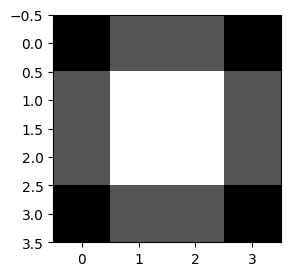

In [23]:
# to visualize the contribution map, you should set input and kernel to matrices of ones
visualize(o)

### Example 2: Bigger factor

In [37]:
# scaling factor = 6
k, s, p = set_ksp((1,1,12,12), 6, 3, ones_k=True)
i = torch.ones(1,2,2)  # (C,H,W)
o = F.conv_transpose2d(input=i, weight=k, stride=s, padding=p)
print("o", o)

o tensor([[[1., 1., 1., 2., 2., 2., 2., 2., 2., 1., 1., 1.],
         [1., 1., 1., 2., 2., 2., 2., 2., 2., 1., 1., 1.],
         [1., 1., 1., 2., 2., 2., 2., 2., 2., 1., 1., 1.],
         [2., 2., 2., 4., 4., 4., 4., 4., 4., 2., 2., 2.],
         [2., 2., 2., 4., 4., 4., 4., 4., 4., 2., 2., 2.],
         [2., 2., 2., 4., 4., 4., 4., 4., 4., 2., 2., 2.],
         [2., 2., 2., 4., 4., 4., 4., 4., 4., 2., 2., 2.],
         [2., 2., 2., 4., 4., 4., 4., 4., 4., 2., 2., 2.],
         [2., 2., 2., 4., 4., 4., 4., 4., 4., 2., 2., 2.],
         [1., 1., 1., 2., 2., 2., 2., 2., 2., 1., 1., 1.],
         [1., 1., 1., 2., 2., 2., 2., 2., 2., 1., 1., 1.],
         [1., 1., 1., 2., 2., 2., 2., 2., 2., 1., 1., 1.]]])


Here is no different, the corners and the frame are just thicker.

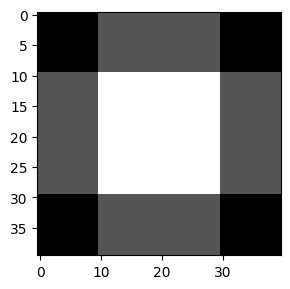

In [27]:
# to visualize the contribution map, you should set input and kernel to matrices of ones
visualize(o)

### Example 3: Bigger input

In [38]:
# scaling factor = 6 (bigger input)
k, s, p = set_ksp((1,1,12,12), 6, 3, ones_k=True)
i = torch.ones(1,30,30)  # (C,H,W)
o = F.conv_transpose2d(input=i, weight=k, stride=s, padding=p)
print("o.shape:", o.shape)

o.shape: torch.Size([1, 180, 180])


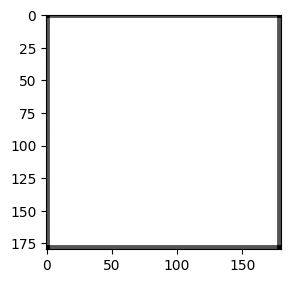

In [39]:
# to visualize the contribution map, you should set input and kernel to matrices of ones
visualize(o)

No diffrence!!!

### Example 4: Different selection method

In [43]:
# scaling factor = 6 (different selection)
k, s, p = set_ksp((1,1,35,35), 5, 0, ones_k=True)
i = torch.ones(1,30,30)  # (C,H,W)
o = F.conv_transpose2d(input=i, weight=k, stride=s, padding=p)
print("o.shape:", o.shape)

o.shape: torch.Size([1, 180, 180])


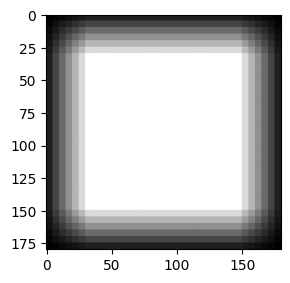

In [44]:
# to visualize the contribution map, you should set input and kernel to matrices of ones
visualize(o)

In [45]:
print(torch.unique(o))

tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 12., 14., 15., 16.,
        18., 20., 21., 24., 25., 28., 30., 35., 36., 42., 49.])


BINGO! This is the checkboard artifacts we were talking about.